1. Import Library

In [ ]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
import datetime
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth berhasil diaktifkan! (Mencegah VRAM Crash)")
    except RuntimeError as e:
        print(e)

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

✅ GPU Memory Growth berhasil diaktifkan! (Mencegah VRAM Crash)
TensorFlow version: 2.21.0
Num GPUs Available: 1


2. Cleaning image

In [4]:
warnings.filterwarnings("ignore", "(Possibly )?corrupt EXIF data", UserWarning)

MASTER_DIR = "EatWise_Premium_Dataset" # Pastikan nama foldernya sudah benar

print(f"Memeriksa file gambar yang korup atau tidak valid di dalam folder '{MASTER_DIR}'...")

valid_count = 0
corrupt_count = 0

# Berjalan menelusuri setiap sub-folder dan file
for root, dirs, files in os.walk(MASTER_DIR):
    for file in files:
        # Hanya mengecek file yang memiliki ekstensi gambar
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
            img_path = os.path.join(root, file)
            try:
                # Mencoba membuka dan memverifikasi bit gambar
                with Image.open(img_path) as img:
                    img.verify() 
                valid_count += 1
            except Exception as e:
                # Jika gagal/korup, otomatis hapus file tersebut agar tidak membuat model crash
                print(f" [HAPUS] File korup ditemukan: {img_path} | Error: {e}")
                os.remove(img_path)
                corrupt_count += 1

print(f"\nPembersihan selesai!")
print(f"Total gambar valid yang siap di-training : {valid_count}")
print(f"Total gambar korup yang berhasil dihapus : {corrupt_count}")

Memeriksa file gambar yang korup atau tidak valid di dalam folder 'EatWise_Premium_Dataset'...

Pembersihan selesai!
Total gambar valid yang siap di-training : 5029
Total gambar korup yang berhasil dihapus : 0


In [ ]:
import os
from PIL import Image

MASTER_DIR = "EatWise_Premium_Dataset"
MAX_DIMENSION = 800 

print("Mencari dan menjinakkan gambar dengan resolusi raksasa (Bom Piksel)...")
count_resized = 0

for root, dirs, files in os.walk(MASTER_DIR):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    width, height = img.size
                    
                    # Jika resolusi gambar melebihi batas 800 piksel
                    if width > MAX_DIMENSION or height > MAX_DIMENSION:
                        # Konversi warna jika format aslinya transparan
                        if img.mode in ("RGBA", "P"):
                            img = img.convert("RGB")
                        
                        # Susutkan dimensi fisik gambar
                        img.thumbnail((MAX_DIMENSION, MAX_DIMENSION))
                        img.save(file_path, format='JPEG', optimize=True, quality=85)
                        count_resized += 1
            except Exception as e:
                pass

print(f"\nSelesai! {count_resized} gambar resolusi raksasa berhasil disusutkan.")

Mencari dan menjinakkan gambar dengan resolusi raksasa (Bom Piksel)...

Selesai! 0 gambar resolusi raksasa berhasil disusutkan.


3. Dataset Preparation

Membangun pipeline tf.data langsung dari direktori...
Found 5018 files belonging to 120 classes.
Using 4015 files for training.


I0000 00:00:1780450455.666344    2203 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 5018 files belonging to 120 classes.
Using 1003 files for validation.

Total Kelas yang Ditemukan: 120

Dataset siap disuapkan ke dalam Model (Tanpa Cache agar RAM aman)!


I0000 00:00:1780450471.634964   72860 shuffle_dataset_op.cc:453] ShuffleDatasetV3:16: Filling up shuffle buffer (this may take a while): 216 of 1000
I0000 00:00:1780450472.271984   72860 shuffle_dataset_op.cc:483] Shuffle buffer filled.


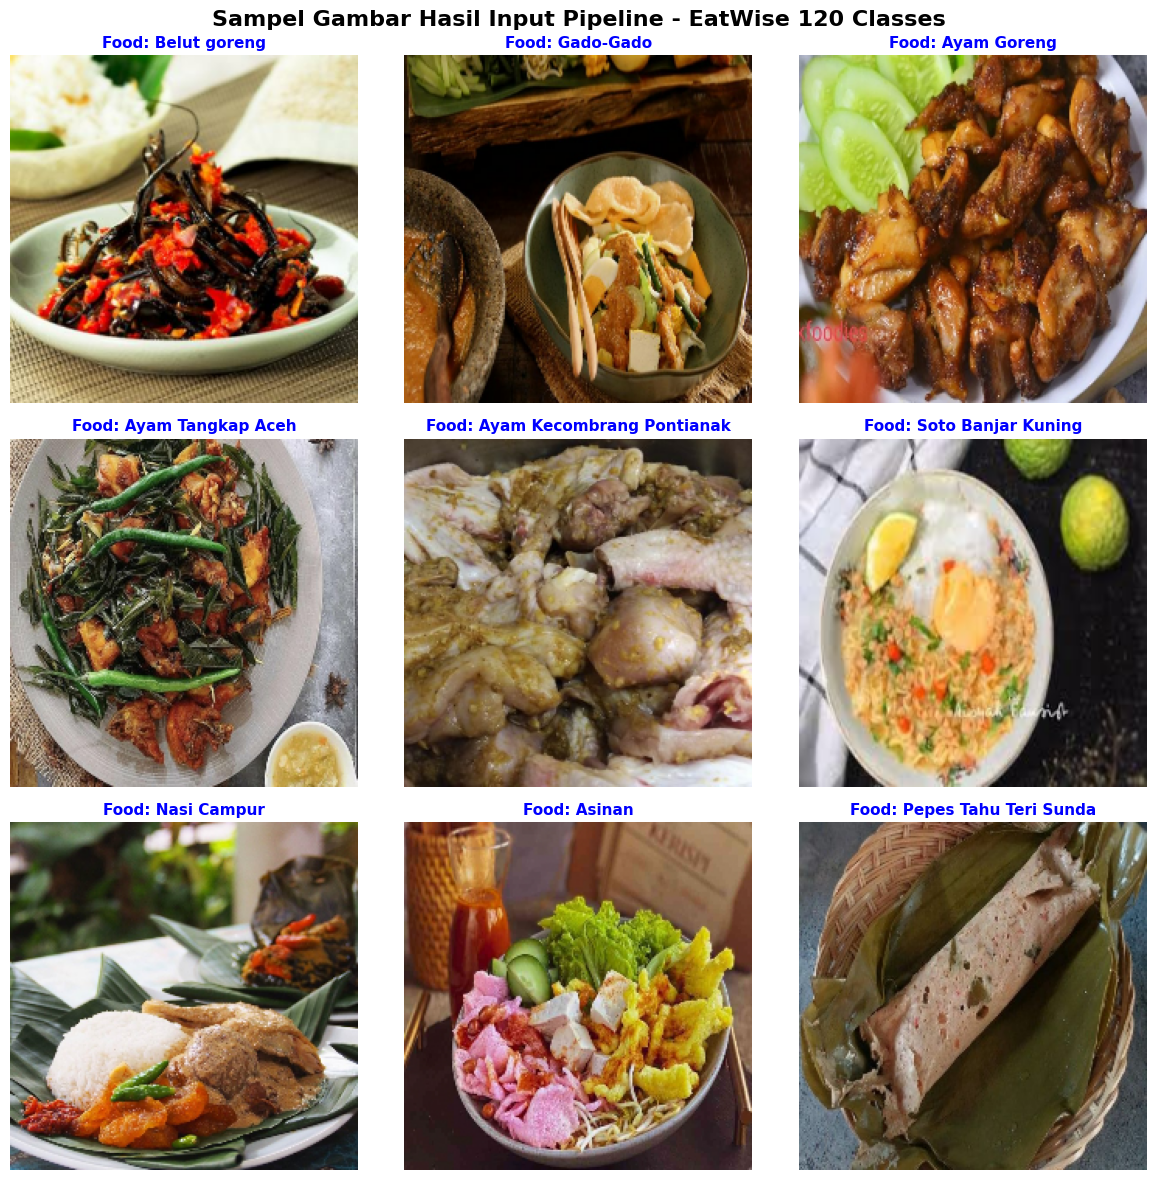

In [ ]:
# 3. Dataset Preparation
MASTER_DIR = "EatWise_Premium_Dataset"
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

print("Membangun pipeline tf.data langsung dari direktori...")

# 1. Memuat Data Training (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    MASTER_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' 
)

# 2. Memuat Data Validasi (20%)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    MASTER_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 3. Ekstrak dan Simpan Nama Kelas untuk app.py nantinya
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"\nTotal Kelas yang Ditemukan: {num_classes}")

with open(f"CLASS_NAMES_{num_classes}.json", "w") as f:
    json.dump(class_names, f, indent=4)

# 4. Optimasi Performa Pipeline untuk GPU (RTX 3060)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

print("\nDataset siap disuapkan ke dalam Model (Tanpa Cache agar RAM aman)!")

# 5. Visualisasi 9 Sampel Gambar Pertama
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(12, 12))
    
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_idx = np.argmax(labels[i].numpy())
        food_name_display = class_names[class_idx].replace('_', ' ')
        plt.title(f"Food: {food_name_display}", color='blue', fontsize=11, weight='bold')
        plt.axis("off")
        
    plt.suptitle(f"Sampel Gambar Hasil Input Pipeline - EatWise {num_classes} Classes", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()
    break

4. Build Custom Model (Functional API)

In [ ]:
def create_eatwise_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3), name="input_gambar")
    

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.4)(x)      
    x = layers.RandomZoom(0.3)(x)          
    x = layers.RandomContrast(0.1)(x)
    x = layers.RandomTranslation(height_factor=0.15, width_factor=0.15)(x) 
    

    base_model = tf.keras.applications.EfficientNetV2B0(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    
    base_model.trainable = True 
    for layer in base_model.layers[:200]:
        layer.trainable = False
        
    x = base_model(inputs, training=False) 
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax', name="output_prediksi")(x)
    
    return Model(inputs=inputs, outputs=outputs, name="EatWise_Optimized_Model")

model = create_eatwise_model(num_classes)
model.summary()

Model: "EatWise_Optimized_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_gambar (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_prediksi (Dense)         │ (None, 120)            │        61,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,638,792 (25.32 MB)

 Trainable params: 3,578,216 (13.65 MB)

 Non-trainable params: 3,060,576 (11.68 MB)

5. Define Custom Loss, Optimizer, dan Metrics

In [ ]:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super(FocalLoss, self).__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = self.alpha * tf.pow(1.0 - y_pred, self.gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=-1))

loss_object = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001) 

train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
train_accuracy_metric = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy')
val_loss_metric = tf.keras.metrics.Mean(name='val_loss')
val_accuracy_metric = tf.keras.metrics.CategoricalAccuracy(name='val_accuracy')

current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_log_dir = 'logs/gradient_tape/' + current_time + '/train'
val_log_dir = 'logs/gradient_tape/' + current_time + '/val'
train_writer = tf.summary.create_file_writer(train_log_dir)
val_writer = tf.summary.create_file_writer(val_log_dir)

6. Custom Training Loop dengan tf.GradientTape

In [ ]:
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        predictions = model(images, training=True)
        loss = loss_object(labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss_metric(loss)
    train_accuracy_metric(labels, predictions)

@tf.function
def val_step(images, labels):
    predictions = model(images, training=False)
    v_loss = loss_object(labels, predictions)
    val_loss_metric(v_loss)
    val_accuracy_metric(labels, predictions)

7. Eksekusi Proses Pelatihan (Training Loop)

In [ ]:
EPOCHS = 100
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
PATIENCE = 15
patience_counter = 0
best_loss = np.inf

print("Memulai Custom Training Loop dengan TensorBoard...\n")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    train_loss_metric.reset_state()
    train_accuracy_metric.reset_state()
    val_loss_metric.reset_state()
    val_accuracy_metric.reset_state()
    
    for images, labels in train_dataset:
        train_step(images, labels)
        
    for val_images, val_labels in val_dataset:
        val_step(val_images, val_labels)
        
    current_train_loss = train_loss_metric.result().numpy()
    current_train_acc  = train_accuracy_metric.result().numpy()
    current_val_loss   = val_loss_metric.result().numpy()
    current_val_acc    = val_accuracy_metric.result().numpy()
    
    history['loss'].append(current_train_loss)
    history['accuracy'].append(current_train_acc)
    history['val_loss'].append(current_val_loss)
    history['val_accuracy'].append(current_val_acc)
    
    with train_writer.as_default():
        tf.summary.scalar('Loss', current_train_loss, step=epoch)
        tf.summary.scalar('Accuracy', current_train_acc, step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('Loss', current_val_loss, step=epoch)
        tf.summary.scalar('Accuracy', current_val_acc, step=epoch)
    
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({epoch_time:.2f}s) -> "
          f"Loss: {current_train_loss:.4f} | Acc: {current_train_acc:.4f} | "
          f"Val Loss: {current_val_loss:.4f} | Val Acc: {current_val_acc:.4f}")

    if current_val_loss < best_loss:
        best_loss = current_val_loss
        patience_counter = 0 
        model.save("eatwise_model_final.keras")
        print(f"  [SAVE] Rekor baru tercipta! Model diamankan dengan Val Loss: {best_loss:.4f}")
    else:
        patience_counter += 1 
        print(f"  [WAIT] Tidak ada peningkatan. Sisa patience: {PATIENCE - patience_counter}")
        
    if patience_counter >= PATIENCE:
        print(f"\n[EARLY STOP] Pelatihan dihentikan pada Epoch {epoch+1}!")
        break

print("\nProses Pelatihan Selesai! Log tersimpan di folder 'logs/gradient_tape'.")

Memulai Custom Training Loop dengan TensorBoard...



W0000 00:00:1780450483.163405    2203 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9641472 bytes after encountering the first element of size 9641472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
E0000 00:00:1780450496.596849    2203 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inEatWise_Optimized_Model_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780450499.020225   72768 cuda_dnn.cc:461] Loaded cuDNN version 92200
W0000 00:00:1780450536.972764   73275 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


Epoch 1/100 (64.01s) -> Loss: 4.8228 | Acc: 0.0797 | Val Loss: 3.7632 | Val Acc: 0.3579
  [SAVE] Rekor baru tercipta! Model diamankan dengan Val Loss: 3.7632


W0000 00:00:1780450546.354169    2203 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9641472 bytes after encountering the first element of size 9641472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1780450568.504664   73407 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


Epoch 2/100 (25.17s) -> Loss: 3.3786 | Acc: 0.3492 | Val Loss: 2.7150 | Val Acc: 0.5523
  [SAVE] Rekor baru tercipta! Model diamankan dengan Val Loss: 2.7150


...

Epoch 93/100 (25.74s) -> Loss: 1.2326 | Acc: 0.9983 | Val Loss: 1.8490 | Val Acc: 0.8335
  [WAIT] Tidak ada peningkatan. Sisa patience: 2


W0000 00:00:1780452948.380103    2203 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9641472 bytes after encountering the first element of size 9641472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1780452970.733150   84178 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


Epoch 94/100 (25.88s) -> Loss: 1.2364 | Acc: 0.9983 | Val Loss: 1.8496 | Val Acc: 0.8235
  [WAIT] Tidak ada peningkatan. Sisa patience: 1


W0000 00:00:1780452996.557891   84287 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


Epoch 95/100 (25.72s) -> Loss: 1.2317 | Acc: 0.9983 | Val Loss: 1.8650 | Val Acc: 0.8285
  [WAIT] Tidak ada peningkatan. Sisa patience: 0

[EARLY STOP] Pelatihan dihentikan pada Epoch 95!

Proses Pelatihan Selesai! Log tersimpan di folder 'logs/gradient_tape'.


8. Visualisasi Performa Model

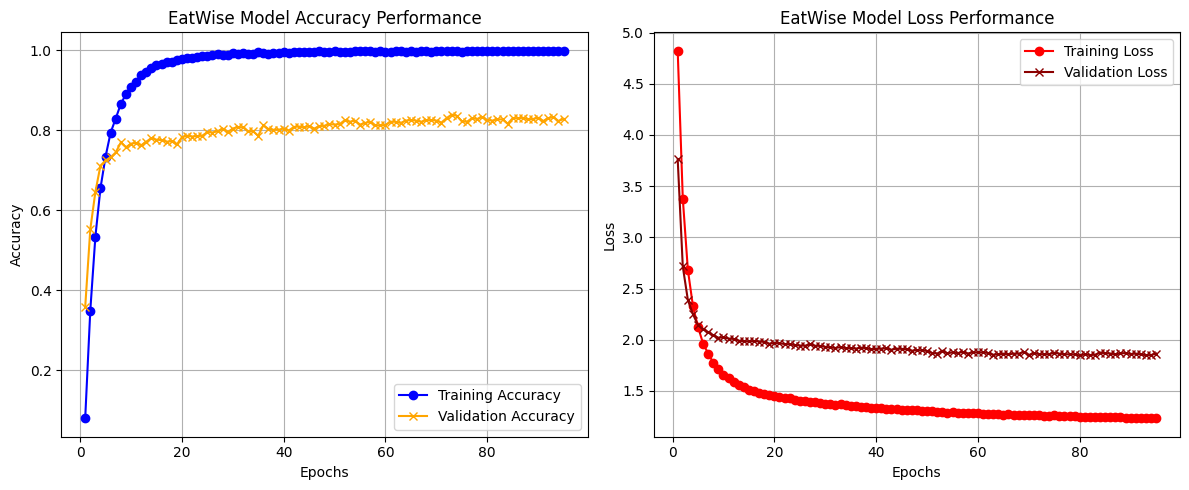


             RANGKUMAN PERFORMA AKHIR MODEL EATWISE             
 -> Total Epoch yang Berjalan      : 95
 -> Akurasi Akhir Training Data    : 99.83%
 -> Akurasi Akhir Testing (Val)    : 82.85%
------------------------------------------------------------
 -> Nilai Akhir Loss Training      : 1.2317
 -> Nilai Akhir Loss Testing (Val) : 1.8650
Model berkinerja SANGAT BAIK (Akurasi Validasi: 82.85%).
   (Catatan: Gap dengan data latih adalah 'Expected Overfitting' yang sangat wajar karena keterbatasan jumlah gambar).


In [ ]:
epochs_range = range(1, len(history['accuracy']) + 1)
plt.figure(figsize=(12, 5))

# 1. Grafik Akurasi (Biru)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['accuracy'], label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', marker='x', color='orange')
plt.title('EatWise Model Accuracy Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Grafik Loss (Merah)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['loss'], label='Training Loss', marker='o', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='x', color='darkred')
plt.title('EatWise Model Loss Performance')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("             RANGKUMAN PERFORMA AKHIR MODEL EATWISE             ")
print("="*60)
print(f" -> Total Epoch yang Berjalan      : {len(history['accuracy'])}")
print(f" -> Akurasi Akhir Training Data    : {history['accuracy'][-1] * 100:.2f}%")
print(f" -> Akurasi Akhir Testing (Val)    : {history['val_accuracy'][-1] * 100:.2f}%")
print("-"*60)
print(f" -> Nilai Akhir Loss Training      : {history['loss'][-1]:.4f}")
print(f" -> Nilai Akhir Loss Testing (Val) : {history['val_loss'][-1]:.4f}")
print("="*60)

# Evaluasi otomatis kondisi kesehatan model
final_train_acc = history['accuracy'][-1] * 100
final_val_acc = history['val_accuracy'][-1] * 100
gap = final_train_acc - final_val_acc

print("="*60)
if final_val_acc >= 75:
    print(f"Model berkinerja SANGAT BAIK (Akurasi Validasi: {final_val_acc:.2f}%).")
    if gap > 15:
        print("   (Catatan: Gap dengan data latih adalah 'Expected Overfitting' yang sangat wajar karena keterbatasan jumlah gambar).")
elif gap > 20:
    print("Peringatan: Model terindikasi Overfitting Parah!\n   (Akurasi Training tinggi, tapi Testing anjlok. Butuh variasi data lebih banyak).")
elif final_train_acc < 60:
    print("Peringatan: Model terindikasi Underfitting!\n   (Model gagal memahami pola masakan. Perlu arsitektur yang lebih dalam).")
else:
    print("Catatan: Performa model stabil dan memiliki kemampuan generalisasi yang baik!")
print("="*60)

9. Evaluasi Model (Confusion Matrix & Classification Report)

Menghitung metrik evaluasi model dari data validasi...


W0000 00:00:1780453009.258719   84314 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile



=== CLASSIFICATION REPORT ===
                            precision    recall  f1-score   support

                 Ares_Bali       1.00      0.60      0.75         5
                    Asinan       0.50      1.00      0.67         1
                Ayam_Bakar       0.80      0.67      0.73         6
               Ayam_Balado       0.33      0.50      0.40         6
               Ayam_Betutu       0.82      0.75      0.78        12
         Ayam_Geprek_Pedas       1.00      0.62      0.77         8
               Ayam_Goreng       0.65      0.73      0.69        15
  Ayam_Goreng_Kremes_Jogja       1.00      1.00      1.00         2
 Ayam_Kecombrang_Pontianak       0.00      0.00      0.00         6
       Ayam_Kemangi_Kampar       0.00      0.00      0.00         3
       Ayam_Palembang_Jawa       0.71      1.00      0.83         5
         Ayam_Pelalah_Bali       1.00      0.25      0.40         4
               Ayam_Penyet       0.80      1.00      0.89         4
                

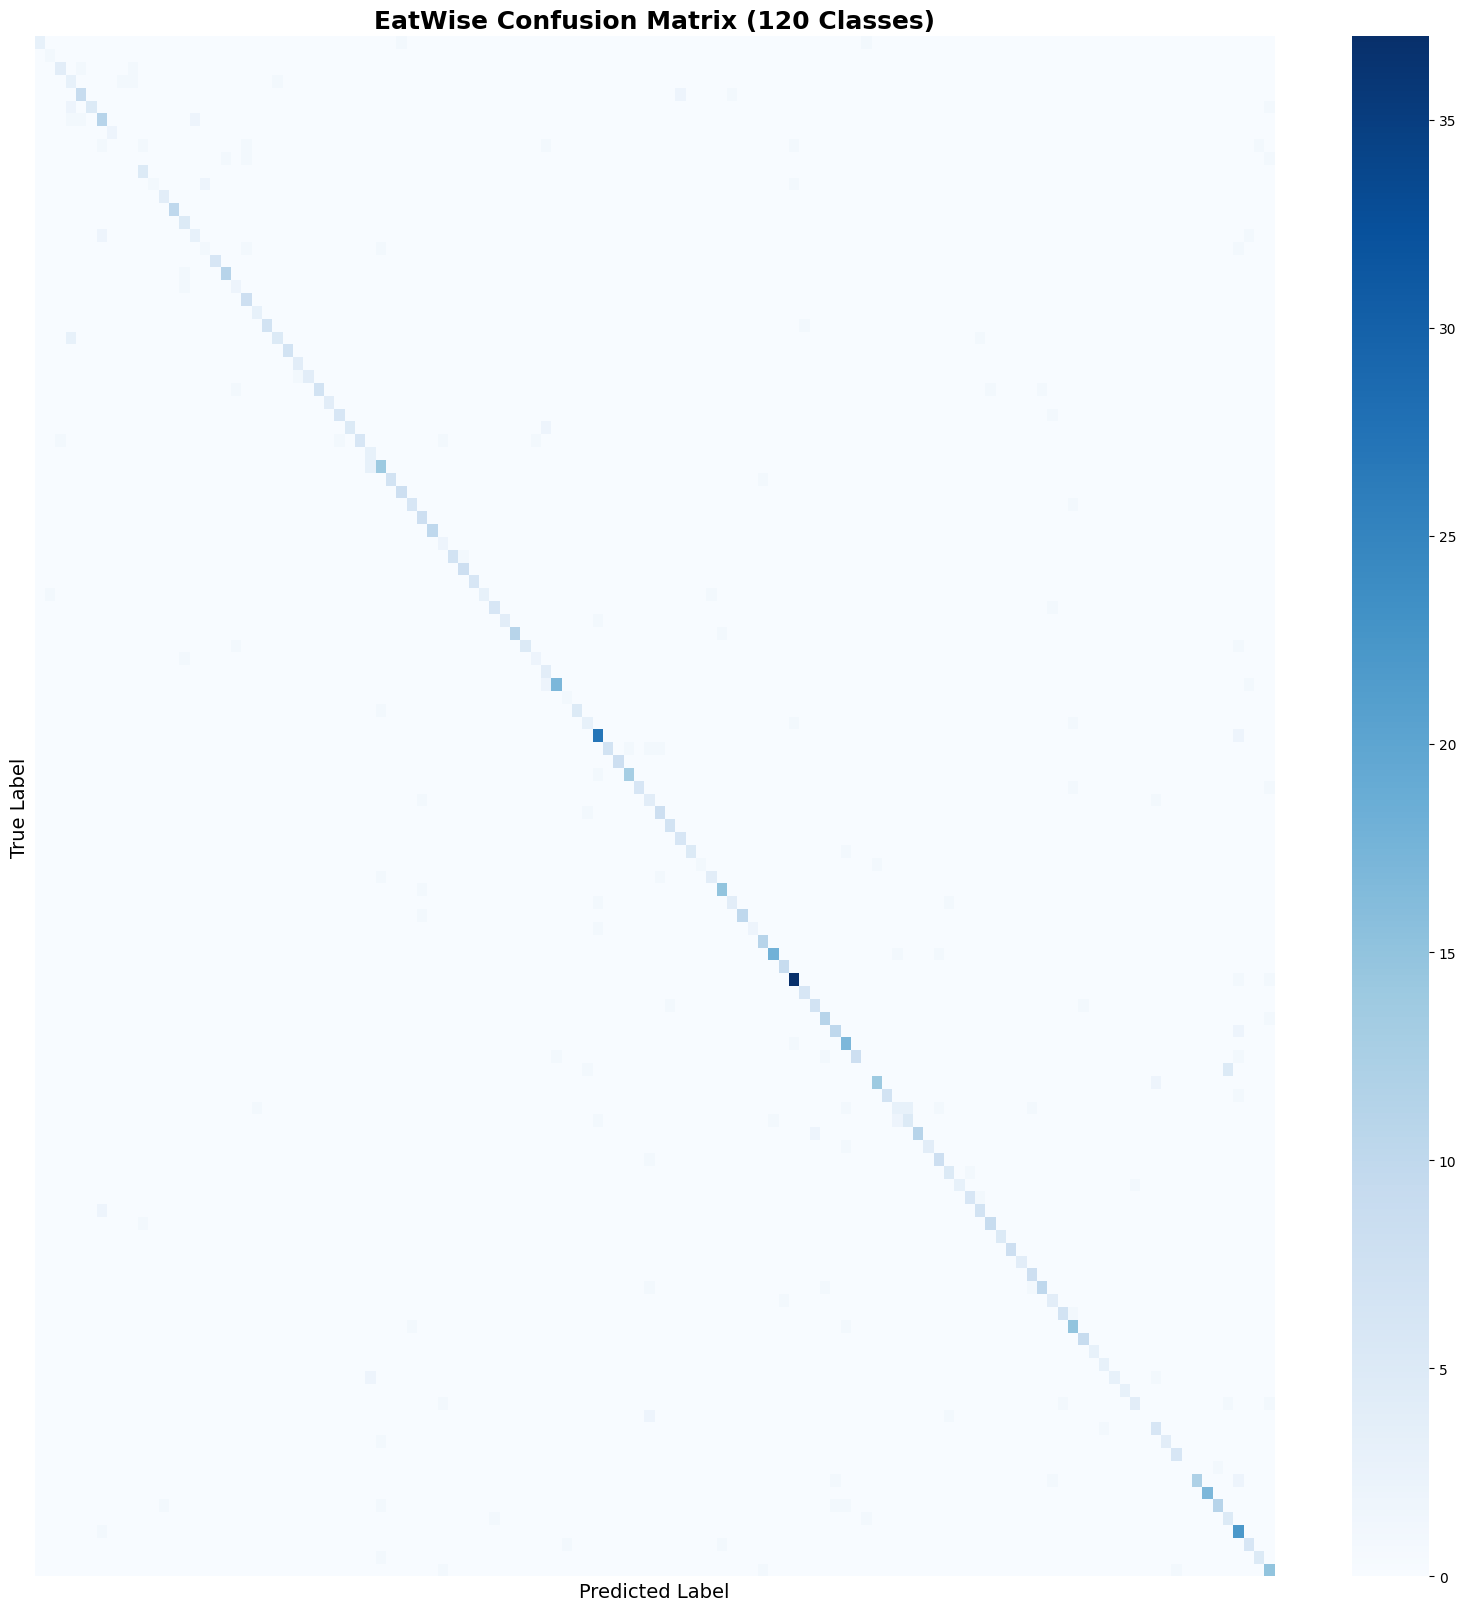

INFO:tensorflow:Assets written to: eatwise_model_saved/assets


INFO:tensorflow:Assets written to: eatwise_model_saved/assets


Saved artifact at 'eatwise_model_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_gambar')
Output Type:
  TensorSpec(shape=(None, 120), dtype=tf.float32, name=None)
Captures:
  126559176090704: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  126559176087824: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  126558929575120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126558929573200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126558929570512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126558929573584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126558929572048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126558929570320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126558929568400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126558929573968: TensorSpec(shape=(), dtype=tf.resource, name

In [ ]:
print("Menghitung metrik evaluasi model dari data validasi...")
all_preds = []
all_true = []

# Kumpulkan prediksi dari data validasi
for images, labels in val_dataset:
    preds = model(images, training=False)
    all_preds.extend(np.argmax(preds.numpy(), axis=1))
    all_true.extend(np.argmax(labels.numpy(), axis=1))

# 1. Tampilkan Classification Report
print("\n=== CLASSIFICATION REPORT ===")
report = classification_report(
    all_true, 
    all_preds, 
    labels=np.arange(len(class_names)), 
    target_names=class_names, 
    zero_division=0
)
print(report)

# 2. Gambar Confusion Matrix
print(f"\n=== CONFUSION MATRIX ({len(class_names)} CLASSES) ===")
# SOLUSI: Tambahkan parameter labels di sini juga
cm = confusion_matrix(all_true, all_preds, labels=np.arange(len(class_names)))

plt.figure(figsize=(20, 20)) 
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title(f'EatWise Confusion Matrix ({len(class_names)} Classes)', fontsize=18, weight='bold')
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.show()

# 3. Simpan Model Akhir 
model.save("eatwise_model_final.keras")
model.export("eatwise_model_saved")
print("\nModel sukses disimpan dengan format .keras!")

10. Inference model from notebook

Menjalankan inference menguji dataset val_dataset...


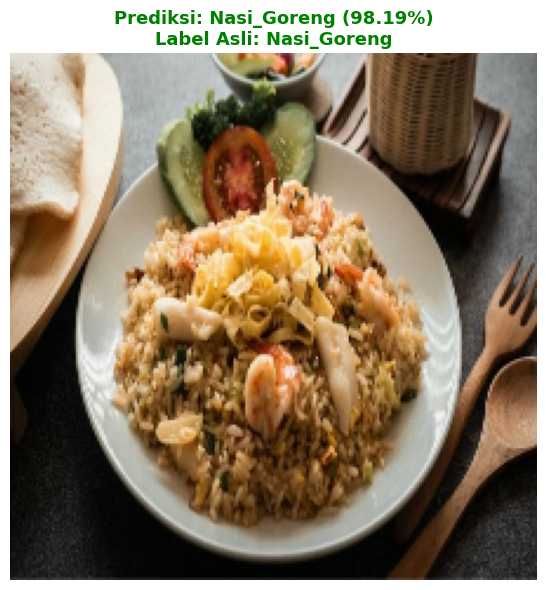

In [13]:
print("Menjalankan inference menguji dataset val_dataset...")

val_dataset_live = val_dataset.unbatch().shuffle(buffer_size=500)

for test_image, random_true_label in val_dataset_live.take(1):
    predictions = model(test_image[tf.newaxis, ...], training=False)
    
    predicted_class_idx = np.argmax(predictions.numpy()[0])
    true_class_idx = np.argmax(random_true_label.numpy())
    confidence_score = predictions.numpy()[0][predicted_class_idx] * 100
    
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image.numpy().astype("uint8"))
    plt.axis('off')
    
    title_color = 'green' if predicted_class_idx == true_class_idx else 'red'
    
    plt.title(f"Prediksi: {class_names[predicted_class_idx]} ({confidence_score:.2f}%)\n"
              f"Label Asli: {class_names[true_class_idx]}", 
              color=title_color, fontsize=13, weight='bold')
    
    plt.tight_layout()
    plt.show()
    break

11. Inference model keras

Memuat berkas model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


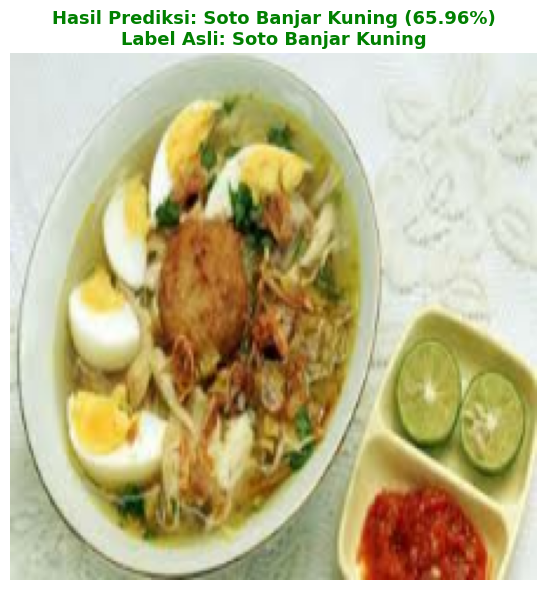

In [ ]:
# 1. Definisikan ulang "cetak biru" Custom Layer & Loss agar Keras mengingatnya
class CustomResidualLayer(layers.Layer):
    def __init__(self, filters, **kwargs):
        super(CustomResidualLayer, self).__init__(**kwargs)
        self.filters = filters
        
    def build(self, input_shape):
        self.conv = layers.Conv2D(self.filters, 3, padding='same', activation='relu')
        self.bn = layers.BatchNormalization()
        super(CustomResidualLayer, self).build(input_shape) 

    def call(self, inputs):
        x = self.conv(inputs)
        return self.bn(x) + inputs
        
    def get_config(self):
        config = super(CustomResidualLayer, self).get_config()
        config.update({"filters": self.filters})
        return config

class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super(FocalLoss, self).__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        
    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = self.alpha * tf.pow(1.0 - y_pred, self.gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=-1))
        
    def get_config(self):
        config = super(FocalLoss, self).get_config()
        config.update({"gamma": self.gamma, "alpha": self.alpha})
        return config

# 2. Muat kembali model utama .keras beserta custom_objects
print("Memuat berkas model...")
custom_objs = {"CustomResidualLayer": CustomResidualLayer, "FocalLoss": FocalLoss}
model_keras = tf.keras.models.load_model("eatwise_model_final.keras", custom_objects=custom_objs)

# 3. Muat daftar 2456 nama kelas makanan dari file JSON
with open("CLASS_NAMES_120.json", "r") as f:
    class_names = json.load(f)

# 4. Ambil 1 gambar acak dari val_dataset
val_dataset_random = val_dataset.unbatch().shuffle(buffer_size=500)

for test_image, random_true_label in val_dataset_random.take(1):
    # 5. Jalankan Inference Model
    predictions = model_keras.predict(test_image[tf.newaxis, ...])
    
    # 6. Ekstrak skor tertinggi hasil prediksi
    predicted_class_idx = np.argmax(predictions[0])
    true_class_idx = np.argmax(random_true_label.numpy())
    confidence_score = predictions[0][predicted_class_idx] * 100
    
    # 7. Tampilkan Citra Jernih dan Hasil Tebakan AI
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image.numpy().astype("uint8"))
    plt.axis('off')
    
    title_color = 'green' if predicted_class_idx == true_class_idx else 'red'
    pred_name = class_names[predicted_class_idx].replace('_', ' ')
    true_name = class_names[true_class_idx].replace('_', ' ')
    
    plt.title(f"Hasil Prediksi: {pred_name} ({confidence_score:.2f}%)\n"
              f"Label Asli: {true_name}", 
              color=title_color, fontsize=13, weight='bold')
    
    plt.tight_layout()
    plt.show()
    break